In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns

import tifffile
from skimage.measure import regionprops_table
import random
import umap
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
#### xy pixel size = 0.1893014, z pixel size = 0.7996567
XY_UM = 0.1893014
Z_UM = 0.7996567

directory = Path(r"z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results")
folders = []
for folder in directory.iterdir():
    if folder.is_dir():
        folders.append(folder)
folders_to_read = [f for f in folders if "noamp" not in f.name and "noim" not in f.name]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")

# Read in the Data (Skip this, already loaded)
- You can now skip this and just read in the data directly from the csv 

In [ ]:
def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    props = props.rename(columns={
        "centroid-0": "nucleus_centroid_z",
        "centroid-1": "nucleus_centroid_y",
        "centroid-2": "nucleus_centroid_x",
    })
    zmax, ymax, xmax = mask.shape
    return props, (int(xmax), int(ymax), int(zmax))

In [ ]:
def check_one(folder: Path):
    """ Sanity check that we can use the NucleiLocation.csv data rather than reading in the segmentation mask each time
    Values of 0 mean the mask matches the csv data
    """
    seg_path = next(iter(folder.glob("*seg_mask.tif*")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)
    if seg_path is None or not xyz_path.exists():
        print("File Missing")
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs().round(3)
    dy = (m["nucleus_centroid_y"] - m["y"]).abs().round(3)
    dz = (m["nucleus_centroid_z"] - m["z"]).abs().round(3)
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
    }

test = folders_to_read[1]
report = pd.DataFrame([check_one(test)])


In [ ]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"

def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    zmax, ymax, xmax = tuple(s for s in shape if s > 1)  # drop singleton axes
    return int(xmax), int(ymax), int(zmax)

all_tables = []

for folder in folders_to_read:
    print(folder)
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask.tif")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue
    if not count_csv.exists():
        print(f"[SKIP - no count_table.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei, extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


# Read Gene Counts (Run from Here)
- iterate through folders and extract counts
- define cells as endothelilal/fibroblast/unknown
- restrict to cells with spots, and with gene IDs that occur in >3 cells

In [8]:
combined = pd.read_csv(output_dir / "all_nuclei.csv")

In [9]:
combined["endothelial_score"] = combined[["CDH5", "PECAM1", "VWF", "KDR", "FLT1" , "PDGFB"]].sum(axis=1)
combined["fibroblast_score"] = combined[["PDGFRB", "COL1A1", "COL1A2"]].sum(axis=1)
combined["cell_type"] = combined.apply(
    lambda row: "endothelial" if row["endothelial_score"] > row["fibroblast_score"] 
        else "unknown" if row["endothelial_score"] == 0 and row["fibroblast_score"] == 0
        else "fibroblast",
    axis=1
)
combined.head()

,source_folder,name,nucleus,CDH5,MMP1,COL1A1,KDR,VWF,PECAM1,VEGFA,...,FP4col15,nucleus_centroid_x,nucleus_centroid_y,nucleus_centroid_z,Xmax,Ymax,Zmax,endothelial_score,fibroblast_score,cell_type
0,dev10_1_day2,dev10_1_day2,1,0,0,0,0,0,0,0,...,0,188.658333,96.013889,76.424074,3915,3940,126,0,0,unknown
1,dev10_1_day2,dev10_1_day2,2,1,0,0,0,0,0,0,...,0,846.045038,291.633028,78.258132,3915,3940,126,1,0,endothelial
2,dev10_1_day2,dev10_1_day2,3,1,0,0,0,0,0,0,...,0,52.089172,149.869182,76.745958,3915,3940,126,1,0,endothelial
3,dev10_1_day2,dev10_1_day2,5,0,0,0,0,0,0,0,...,0,278.323219,1281.867414,75.916887,3915,3940,126,0,0,unknown
4,dev10_1_day2,dev10_1_day2,6,0,0,0,2,0,0,0,...,0,334.438947,1340.122905,77.061852,3915,3940,126,2,0,endothelial


In [10]:
# Tidy matrix: genes are either on (1+ counts) or off (0 counts). Drop FP readouts and create a readable gene state for on genes (e.g. 1_4_12)
metadata_cols = {
    "name", "source_folder", "nucleus",
    "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z", 
    "Xmax", "Ymax", "Zmax", "cell_type", "endothelial_score", "fibroblast_score",
    "state_code",  # derived label columns, not genes
}
gene_columns = [c for c in combined.columns if c not in metadata_cols]
fp_columns = [c for c in gene_columns if c.startswith("FP")]
true_gene_columns = [c for c in gene_columns if not c.startswith("FP")]

combined[true_gene_columns] = (combined[true_gene_columns].fillna(0).astype(float) > 0).astype(int)
combined["state_code"] = combined[true_gene_columns].apply(
    lambda row: "_".join(str(i + 1) for i, value in enumerate(row) if value == 1), axis=1,
).replace("", "0")  # all-negative cells get the code "0"
true_gene_dictionary = {c: i for i, c in enumerate(true_gene_columns)}

# # binary_state: one digit per gene in column order, e.g. "100100000001000000"
combined["binary_state"] = combined[true_gene_columns].astype(str).agg("".join, axis=1)

In [11]:
# Keep biologically informative cells and recurrent states.
min_cells_per_state = 3                       # states must occur in > 2 cells
cells_with_spots = combined[combined["binary_state"] != "0" * len(true_gene_columns)].copy()  # drop all-negative cells (no transcripts detected -> not interesting)

In [12]:
state_counts = cells_with_spots["state_code"].value_counts()
recurrent_states = state_counts[state_counts >= min_cells_per_state].index
df_recurrent = cells_with_spots[cells_with_spots["state_code"].isin(recurrent_states)].copy()

n_total = len(combined)
print(f"All cells:                         {n_total:,}")
print(f"Cells with >=1 transcript:         {len(cells_with_spots):,} ({100*len(cells_with_spots)/n_total:.1f}%)")
print(f"Unique expressed states:           {state_counts.size:,}")
print(f"Recurrent states (> 2 cells):      {len(recurrent_states):,}")
print(f"Cells in recurrent states:         {len(df_recurrent):,} ({100*len(df_recurrent)/n_total:.1f}%)")

All cells:                         13,047
Cells with >=1 transcript:         9,472 (72.6%)
Unique expressed states:           1,555
Recurrent states (> 2 cells):      394
Cells in recurrent states:         8,058 (61.8%)


# Spatial & genetic subpopulation analysis

Everything below operates on **`df_recurrent`** - cells with **>=1 transcript** that
fall in a **recurrent gene state** (a state seen in >=3 cells). The *Initial Data
Exploration* section and all cells beneath it are left untouched.

**Coordinates** are converted to microns using the acquisition pixel sizes
(xy = 0.1893014 um, z = 0.7996567 um), and every spatial calculation is performed
*within each image* (`source_folder`) so neighbourhoods never span different images.

**Roadmap**
1. **Pairwise gene interactions** - all cells, then endothelial and fibroblast separately.
2. **Gene states -> cell states** - hierarchical clustering, UMAP, Leiden, and a
   Bernoulli mixture model, comparing an unsupervised vs a probabilistic view so we can
   trust the structure is biological rather than an artefact of one algorithm.
3. **Neighbourhood analysis** - per-cell micro-environment (composition, nearby
   expression, Shannon diversity, density), then clustering neighbourhoods into niches.
4. **Graph-based approaches** - a spatial cell graph (communities + neighbour
   enrichment) and a gene-state graph (states linked when they differ by one gene).

## 0. Setup - analysis frame & physical coordinates


In [13]:
# Convert to physical coordinates witin the image (each image has its own coordinate origin)
GENES = list(true_gene_columns)      # the 18 real genes (FP channels excluded)
IMAGE_KEY = "source_folder"          # one physical image per source_folder

# Working frame + physical coordinates.
df = df_recurrent.copy().reset_index(drop=True)
df["x_um"] = df["nucleus_centroid_x"] * XY_UM
df["y_um"] = df["nucleus_centroid_y"] * XY_UM
df["z_um"] = df["nucleus_centroid_z"] * Z_UM

# Binary gene matrix (cells x genes) reused throughout.
X = df[GENES].astype(int).to_numpy()

# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}

print("\nCell-type counts:")
print(df["cell_type"].value_counts())



Cell-type counts:
cell_type
endothelial    6173
unknown        1200
fibroblast      685
Name: count, dtype: int64


## 1. Pairwise gene interactions

Which genes tend to switch on together, and which are mutually exclusive? For every gene
pair we build a 2x2 on/off contingency table, compute the odds ratio, and test it with
**Fisher's exact test** (Benjamini-Hochberg FDR). We look at all recurrent cells first,
then repeat **separately for endothelial and fibroblast cells**, since co-expression
programmes are expected to differ by lineage.


In [ ]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=20, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

In [ ]:
#  All recurrent cells 
res_all, M_all = pairwise_cooccurrence(
    df, GENES, title="All recurrent cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

# Readable labels for the summary tables.
show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nStrongest co-occurring gene pairs:")
display(sig.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
print("Strongest mutually-exclusive gene pairs:")
display(sig.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))

In [ ]:
#  Split by cell type: do the interaction patterns differ by type?
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
pair_by_type = {}
all_res = []
for ax, label in zip(axes, ["endothelial", "fibroblast"]):
    sub = df[df.cell_type == label]
    res, _ = pairwise_cooccurrence(sub, GENES, ax=ax,
                                   title=f"{label} cells (n={len(sub):,}) - log2 OR")
    pair_by_type[label] = res
    all_res.append(res.assign(cell_type=label))
plt.tight_layout()
plt.show()

In [ ]:
for res, label in zip(all_res, ["endothelial", "fibroblast"]):
    sig = res[res.FDR < 0.05].copy()
    print(f"Significant {label} pairs (FDR<0.05): {len(sig)}  "
        f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("\nStrongest co-occurring gene pairs:")
    display(sig.sort_values("log2_OR", ascending=False).head(10)[cols].rename(columns=show_cols))
    print(f"Strongest mutually-exclusive {label} gene pairs:")
    display(sig.sort_values("log2_OR").head(10)[cols].rename(columns=show_cols))

## 2. Which gene states define distinct cell states?

**Biological question:** we've converted the on/off genes into a single 18-gene state. Can we group those into families of cell state? Are these groups robust if we use different approaches to identify them.
We split into cell type, otherwise the main identified differences will be endothelial vs fibroblast

Several ways to try and group the cell state:

| Approach | Type | What "similar" means biologically |
|---|---|---|
| Hierarchical (Jaccard) | unsupervised | states are similar when they switch **on the same genes** (jointly-off genes ignored) |
| Hierarchical (Hamming) | unsupervised | states are similar when they **agree on on *and* off** genes (off genes count) |
| KMeans (at matched K) | unsupervised | Euclidean clustering of the 0/1 gene vectors - groups cells by their **overall on/off profile** (close to Hamming) |
| UMAP | visualisation | 2-D embedding of the Jaccard neighbour graph (shared **on** genes) |
| Bernoulli mixture | probabilistic | generative on/off model; genes independent given state, K chosen by BIC |

To compare the methods fairly, the Bernoulli mixture picks the number of states **K** (by BIC) and that same K is **forced on KMeans and hierarchical**, so a low agreement means genuine disagreement rather than a granularity mismatch. (Leiden on the Jaccard graph is kept in the code as an optional view, but it leaves rare states stranded in a merged "other" cluster and so lines up poorly; KMeans is used as the third method instead.)

**Jaccard vs Hamming** is the key choice. Jaccard measures overlap of the genes
that are *on* genes only, so two cells are similar only when they co-express the
same markers, but shared "off" genes don't count towards "similarity". Hamming counts every gene
that differs, so two mostly-silent cells look similar just for sharing their *off* genes.
Jaccard therefore asks "which genes are co-activated?", Hamming asks "how identical are the
full profiles, off genes included included?".

- "jaccard": distance uses only the genes that are ON in at least one of the two
    states (shared-on / union-on). States are similar when they switch on the *same*
    genes; jointly-off genes are ignored. Best when co-expression of specific markers
    defines a programme and the many silent genes should not drive similarity
- "hamming": fraction of *all* genes that differ, so agreement on OFF genes also
    counts as similarity. Mostly-silent states then cluster together simply for being
    silent.

**Agreement across methods:** a high Adjusted Rand Index between an **unsupervised** method
(KMeans / hierarchical) and the **probabilistic** Bernoulli mixture tells us the structure
is real biology rather than an artefact of one clustering choice.


In [25]:
# Shared helpers + a readable cluster summariser used by every approach in section 2.

def build_state_matrix(cells, genes):
    """Collapse cells down to their unique gene states.

    Returns:
        state_matrix    - one row per distinct on/off pattern, one column per gene
                          (0/1), ordered from most to least common.
        cells_per_state - how many cells carry each state (same row order).
    """
    cells_per_state = cells.groupby("binary_state").size().sort_values(ascending=False)
    state_matrix = pd.DataFrame(
        [[int(bit) for bit in state] for state in cells_per_state.index],
        index=cells_per_state.index, columns=genes,
    )
    return state_matrix, cells_per_state


def binary_state_to_code(binary_state):
    """'100100...' -> '1_4' (1-indexed positions of the ON genes; '0' if none on)."""
    genes_on = [str(position + 1) for position, bit in enumerate(binary_state) if bit == "1"]
    return "_".join(genes_on) if genes_on else "0"


def state_code_to_gene_names(state_code, genes):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the 1-indexed gene order ('0' -> 'none')."""
    if state_code == "0":
        return "none"
    return ", ".join(genes[int(position) - 1] for position in state_code.split("_"))


def describe_clusters(cells, cell_labels, genes, method_name, cell_type, top_states=3):
    """Print a plain-English summary of one method's clusters for one cell type.

    For every cluster it lists the gene states that dominate it, e.g.
    "cluster 1 (120 cells, 34%): likely states include 60% 1_4 (CDH5, KDR); ...".
    Cells with label -1 (unassigned) are ignored. Returns the same information as a
    tidy DataFrame so it can be collected and saved.
    """
    labels = pd.Series(cell_labels, index=cells.index)
    assigned = labels[labels >= 0]
    cluster_sizes = assigned.value_counts()
    n_cells = len(assigned)
    print(f"{len(cluster_sizes)} clusters identified for {cell_type} cells "
          f"({method_name}, {n_cells:,} cells):")

    summary_rows = []
    for cluster_id in cluster_sizes.index:
        member_index = assigned[assigned == cluster_id].index
        n = len(member_index)
        state_counts = cells.loc[member_index, "binary_state"].value_counts()
        described = [
            f"{100 * count / n:.0f}% {binary_state_to_code(state)} "
            f"({state_code_to_gene_names(binary_state_to_code(state), genes)})"
            for state, count in state_counts.head(top_states).items()
        ]
        main_states = "; ".join(described)
        print(f"  cluster {cluster_id} ({n:,} cells, {100 * n / n_cells:.0f}%): "
              f"likely states include {main_states}")
        summary_rows.append({
            "cell_type": cell_type,
            "method": method_name,
            "cluster": cluster_id,
            "n_cells": n,
            "pct_of_cell_type": 100 * n / n_cells,
            "main_states": main_states,
        })
    print()
    return pd.DataFrame(summary_rows)


# ---- Approach 1: hierarchical clustering of gene states ----

def hierarchical_cell_labels(cells, genes, metric="jaccard", max_clusters=8):
    """Cluster the unique gene states, then hand each cell its state's cluster.

    Biological question: do the on/off gene patterns fall into a few recurring
    programmes ("cell states") within this lineage?

    The `metric` decides what "similar" means:
        "jaccard" - similar when states share the same ON genes (OFF genes ignored).
        "hamming" - similar when states agree on ON and OFF genes (silent genes count).
    States are joined with average linkage and the tree is cut so it yields at most
    `max_clusters` groups (keeps the summary readable).

    Returns:
        cell_labels - one cluster id per cell (all -1 if too few states to cluster).
        plot_bundle - (state_matrix, linkage_tree, cluster_ids) for the clustermap,
                      or None when clustering was skipped.
    """
    state_matrix, _ = build_state_matrix(cells, genes)
    if len(state_matrix) < 3:
        return np.full(len(cells), -1), None
    linkage_tree = linkage(pdist(state_matrix.values, metric=metric), method="average")
    n_clusters = min(max_clusters, len(state_matrix))
    cluster_ids = fcluster(linkage_tree, t=n_clusters, criterion="maxclust")
    state_to_cluster = pd.Series(cluster_ids, index=state_matrix.index)
    cell_labels = cells["binary_state"].map(state_to_cluster).to_numpy()
    return cell_labels, (state_matrix, linkage_tree, cluster_ids)


def plot_state_clustermap(state_matrix, linkage_tree, cluster_ids, cell_type, n_cells):
    """Clustermap of the gene states for one cell type, rows coloured by cluster."""
    cluster_colors = [sns.color_palette("tab20", cluster_ids.max())[c - 1] for c in cluster_ids]
    grid = sns.clustermap(
        state_matrix, row_linkage=linkage_tree, col_cluster=False, cmap="Greys",
        row_colors=cluster_colors, yticklabels=False, cbar_pos=None,
        figsize=(9, min(14, 0.18 * len(state_matrix) + 3)))
    grid.ax_heatmap.set_xlabel("Gene")
    grid.figure.suptitle(
        f"{cell_type}: {len(state_matrix)} gene states ({n_cells:,} cells) "
        f"-> {cluster_ids.max()} clusters", y=1.02)
    plt.show()


In [22]:
#  Approach 2: Bernoulli mixture (probabilistic) 

def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for _ in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, and the
    BIC score (lower = better fit once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for _ in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states



In [34]:
# Approach 3: KMeans (at matched K) + UMAP on the gene vectors
# (Leiden is kept below as an optional graph-based view but is no longer the third
# method in the run-all cell - KMeans lines up far better with the other two.)

def merge_small_clusters(labels, max_clusters):
    """Keep the largest clusters, fold the rest into one 'other' group.

    Guarantees at most `max_clusters` labels and renumbers them 0..n-1 by size
    (the merged 'other' group, if any, is the last id). Needed because rare gene
    states form disconnected islands in the graph that resolution tuning can't merge.
    """
    sizes = pd.Series(labels).value_counts()
    if len(sizes) <= max_clusters:
        remap = {old: new for new, old in enumerate(sizes.index)}
        return np.array([remap[label] for label in labels])
    kept = list(sizes.index[:max_clusters - 1])
    remap = {old: new for new, old in enumerate(kept)}
    other_id = max_clusters - 1
    return np.array([remap.get(label, other_id) for label in labels])


def kmeans_cluster_gene_space(gene_matrix, n_clusters, seed=0):
    """Cluster cells directly on their 0/1 gene vectors with KMeans at exactly K.

    Euclidean KMeans on binary vectors groups cells by their overall on/off profile
    (close to Hamming), giving a third view forced to the same K so it is directly
    comparable with the Bernoulli mixture and hierarchical clustering. Unlike the
    graph/Leiden view it never leaves rare states stranded in an 'other' bucket.
    """
    n_clusters = min(n_clusters, len(np.unique(gene_matrix, axis=0)))
    return KMeans(n_clusters=n_clusters, n_init=10, random_state=seed).fit_predict(gene_matrix)


def leiden_cluster_gene_space(gene_matrix, k_neighbors=15, seed=0, max_clusters=8, n_clusters=None):
    """Cluster cells by shared ON genes.

    Builds a k-nearest-neighbour graph with the Jaccard metric (cells are neighbours
    when they switch on the same genes; shared OFF genes are ignored) and finds
    communities in it with Leiden.

    If `n_clusters` is given the resolution is *raised* until at least that many
    communities appear, then they are merged down to exactly `n_clusters` (used to
    match the K chosen by the Bernoulli mixture so the methods are comparable).
    Otherwise the resolution is *lowered* until at most `max_clusters` communities
    remain. Either way leftover rare-state islands are folded into a single 'other'
    cluster. Returns one label per cell.
    """
    neighbors = NearestNeighbors(n_neighbors=k_neighbors, metric="jaccard").fit(gene_matrix)
    _, neighbor_index = neighbors.kneighbors(gene_matrix)
    edges = {(min(cell, int(other)), max(cell, int(other)))
             for cell in range(neighbor_index.shape[0]) for other in neighbor_index[cell, 1:]}
    graph = ig.Graph(n=len(gene_matrix), edges=list(edges))

    def partition_at(resolution):
        return np.array(leidenalg.find_partition(
            graph, leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=resolution, seed=seed).membership)

    if n_clusters is not None:
        labels = None
        for resolution in [0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
            labels = partition_at(resolution)
            if len(set(labels)) >= n_clusters:
                break
        return merge_small_clusters(labels, n_clusters)

    labels = None
    for resolution in [1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.01]:
        labels = partition_at(resolution)
        if len(set(labels)) <= max_clusters:
            break
    return merge_small_clusters(labels, max_clusters)


def umap_embed_gene_space(gene_matrix, k_neighbors=15, seed=0):
    """2-D UMAP of the same Jaccard neighbour structure - for visualisation only."""
    return umap.UMAP(metric="jaccard", n_neighbors=k_neighbors, min_dist=0.1,
                     random_state=seed).fit_transform(gene_matrix)

CELL TYPE: endothelial  (6,173 cells)
Bernoulli BIC picked K = 7; forcing K on KMeans and hierarchical.

7 clusters identified for endothelial cells (Bernoulli mixture, 6,173 cells):
  cluster 3 (1,652 cells, 27%): likely states include 28% 4 (KDR); 16% 1_4 (CDH5, KDR); 11% 1_4_7 (CDH5, KDR, VEGFA)
  cluster 2 (1,228 cells, 20%): likely states include 54% 1 (CDH5); 21% 1_7 (CDH5, VEGFA); 4% 1_2 (CDH5, MMP1)
  cluster 1 (988 cells, 16%): likely states include 7% 1_4_5_7 (CDH5, KDR, VWF, VEGFA); 4% 1_7_8 (CDH5, VEGFA, DLL4); 3% 1_4_8 (CDH5, KDR, DLL4)
  cluster 5 (986 cells, 16%): likely states include 12% 1_6 (CDH5, PECAM1); 12% 6 (PECAM1); 9% 1_4_6 (CDH5, KDR, PECAM1)
  cluster 4 (690 cells, 11%): likely states include 32% 5 (VWF); 26% 1_5 (CDH5, VWF); 16% 1_5_7 (CDH5, VWF, VEGFA)
  cluster 6 (421 cells, 7%): likely states include 14% 13 (PDGFB); 9% 1_13 (CDH5, PDGFB); 7% 1_7_13 (CDH5, VEGFA, PDGFB)
  cluster 0 (208 cells, 3%): likely states include 15% 12 (FLT1); 10% 1_12 (CDH5, FLT1)

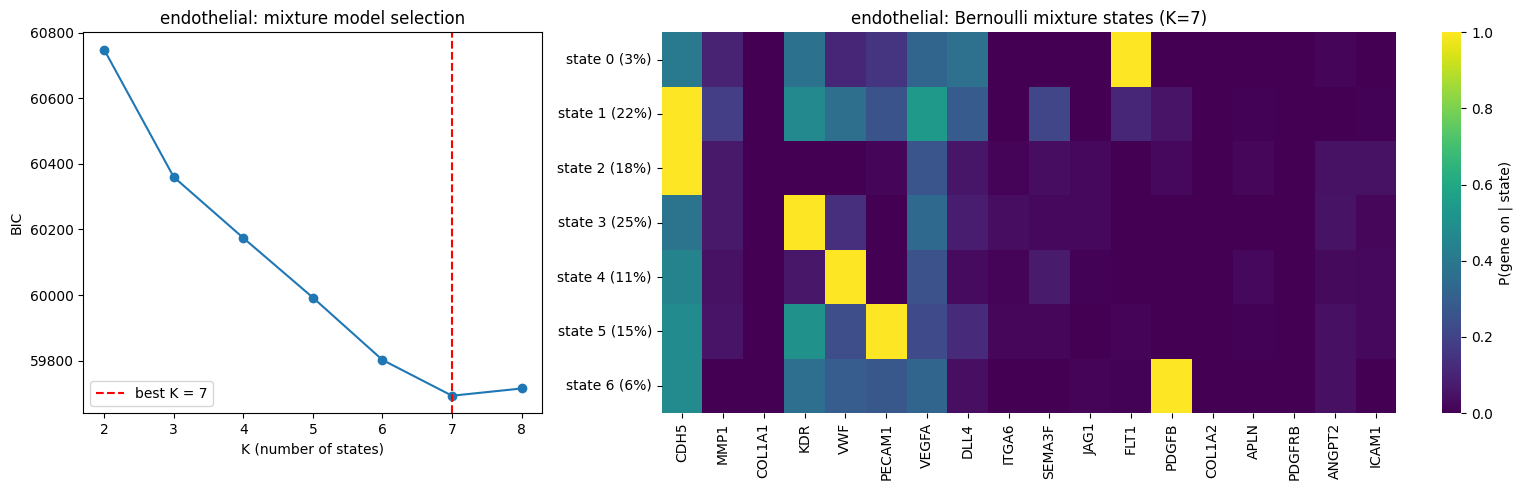

7 clusters identified for endothelial cells (KMeans, 6,173 cells):
  cluster 5 (1,215 cells, 20%): likely states include 54% 1 (CDH5); 15% 1_5 (CDH5, VWF); 5% 1_2 (CDH5, MMP1)
  cluster 6 (1,106 cells, 18%): likely states include 42% 4 (KDR); 16% 4_7 (KDR, VEGFA); 6% 4_5 (KDR, VWF)
  cluster 0 (1,060 cells, 17%): likely states include 25% 1_4 (CDH5, KDR); 18% 1_4_7 (CDH5, KDR, VEGFA); 8% 1_4_5 (CDH5, KDR, VWF)
  cluster 4 (932 cells, 15%): likely states include 13% 1_6 (CDH5, PECAM1); 10% 1_4_6 (CDH5, KDR, PECAM1); 10% 4_6 (KDR, PECAM1)
  cluster 3 (771 cells, 12%): likely states include 33% 1_7 (CDH5, VEGFA); 14% 1_5_7 (CDH5, VWF, VEGFA); 5% 1_6_7 (CDH5, PECAM1, VEGFA)
  cluster 1 (756 cells, 12%): likely states include 30% 5 (VWF); 15% 6 (PECAM1); 8% 13 (PDGFB)
  cluster 2 (333 cells, 5%): likely states include 12% 1_10 (CDH5, SEMA3F); 9% 1_7_10 (CDH5, VEGFA, SEMA3F); 7% 1_5_10 (CDH5, VWF, SEMA3F)

Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): jaccard = 0.102, hammi

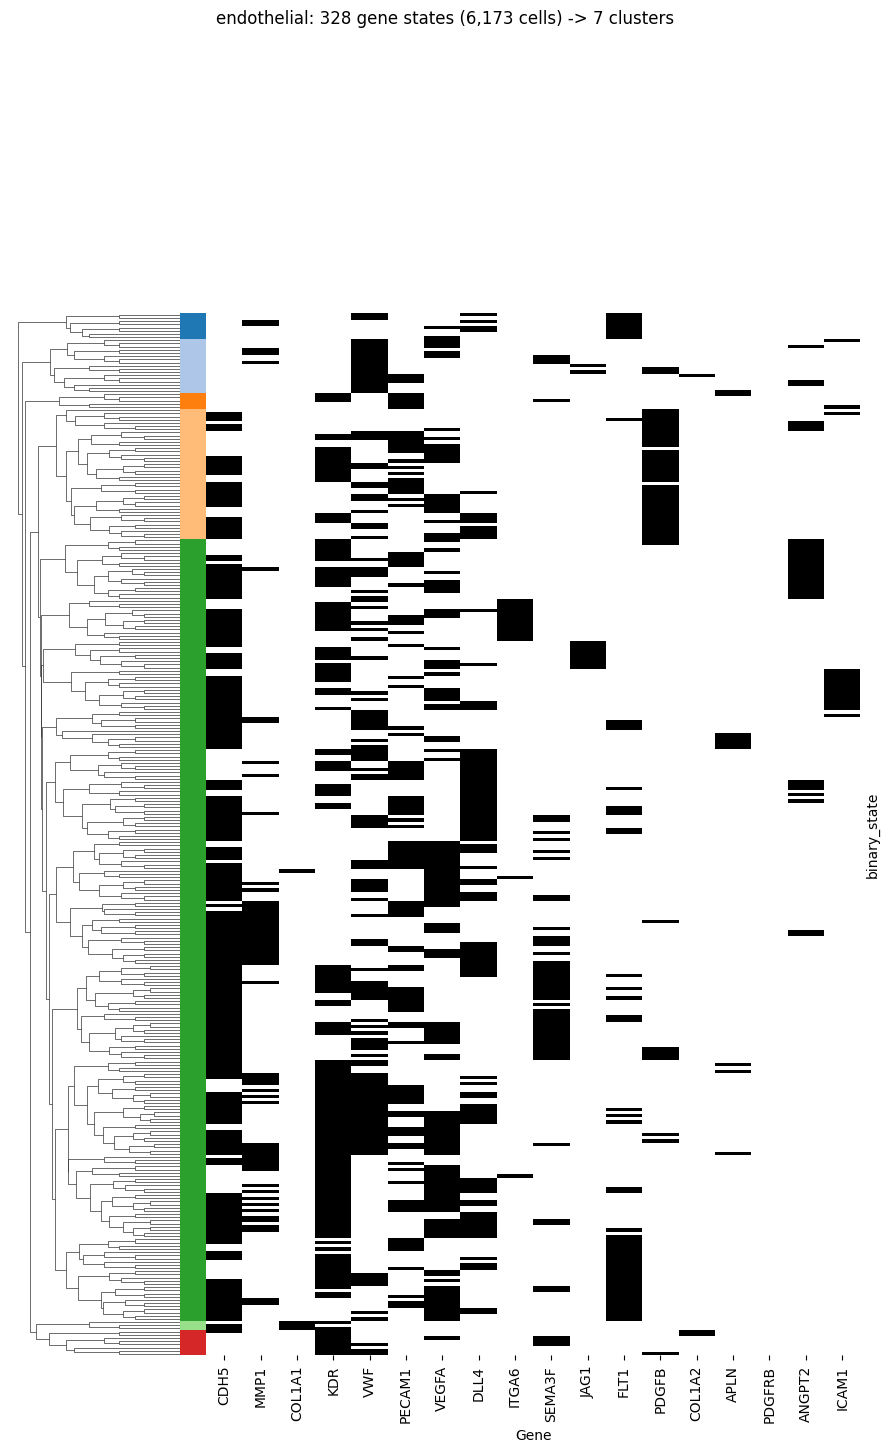

c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


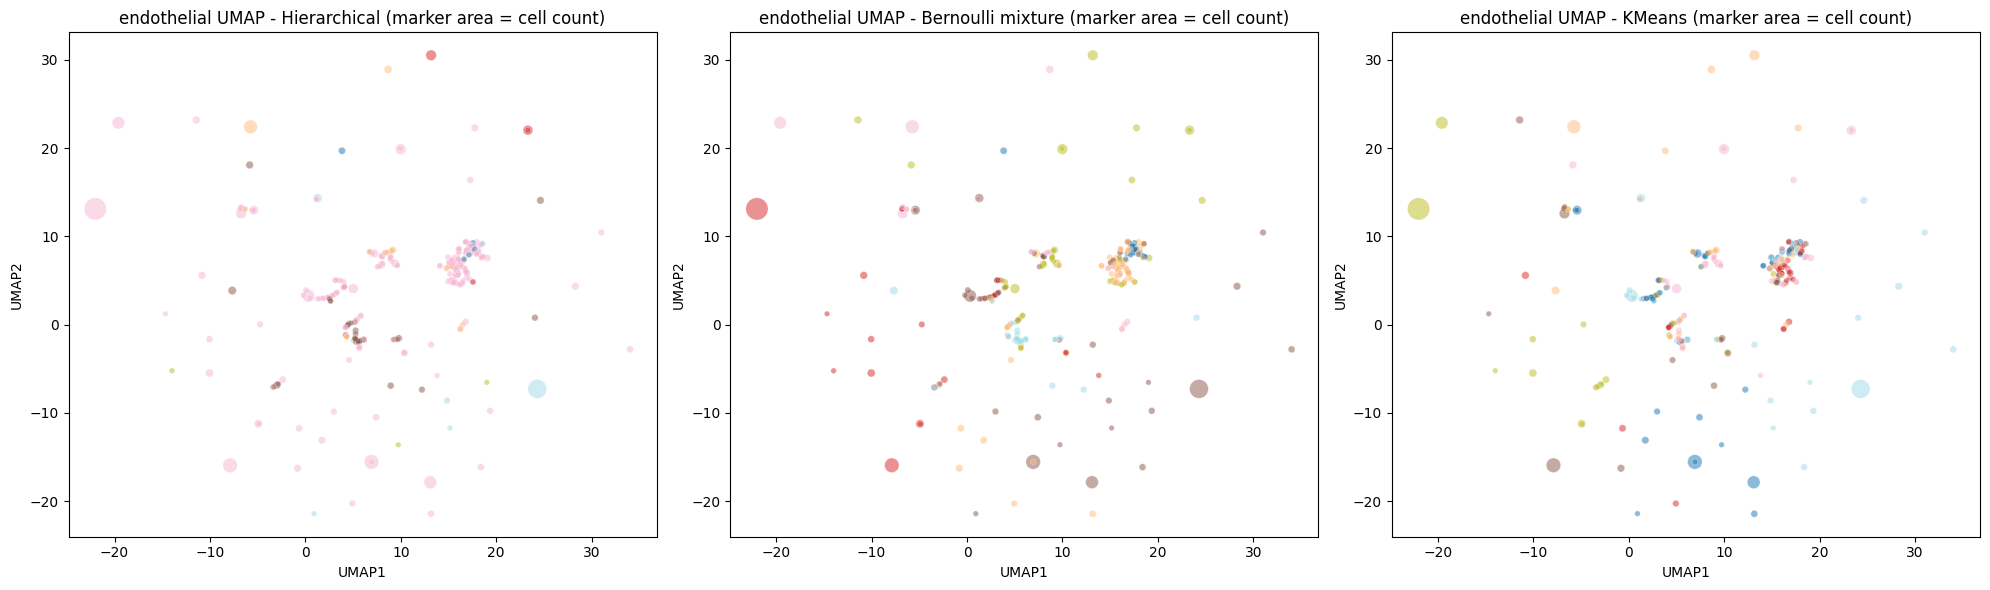

Agreement for endothelial at K=7 (Adjusted Rand Index, 1 = identical, ~0 = chance):
        kmeans vs bernoulli   : ARI = 0.396
        kmeans vs hierarchical: ARI = 0.094
     bernoulli vs hierarchical: ARI = 0.110

CELL TYPE: fibroblast  (685 cells)
Bernoulli BIC picked K = 3; forcing K on KMeans and hierarchical.

3 clusters identified for fibroblast cells (Bernoulli mixture, 685 cells):
  cluster 0 (472 cells, 69%): likely states include 22% 3_14 (COL1A1, COL1A2); 17% 3 (COL1A1); 16% 3_7 (COL1A1, VEGFA)
  cluster 2 (159 cells, 23%): likely states include 48% 14 (COL1A2); 30% 7_14 (VEGFA, COL1A2); 6% 11_14 (JAG1, COL1A2)
  cluster 1 (54 cells, 8%): likely states include 48% 16 (PDGFRB); 20% 7_16 (VEGFA, PDGFRB); 9% 1_16 (CDH5, PDGFRB)



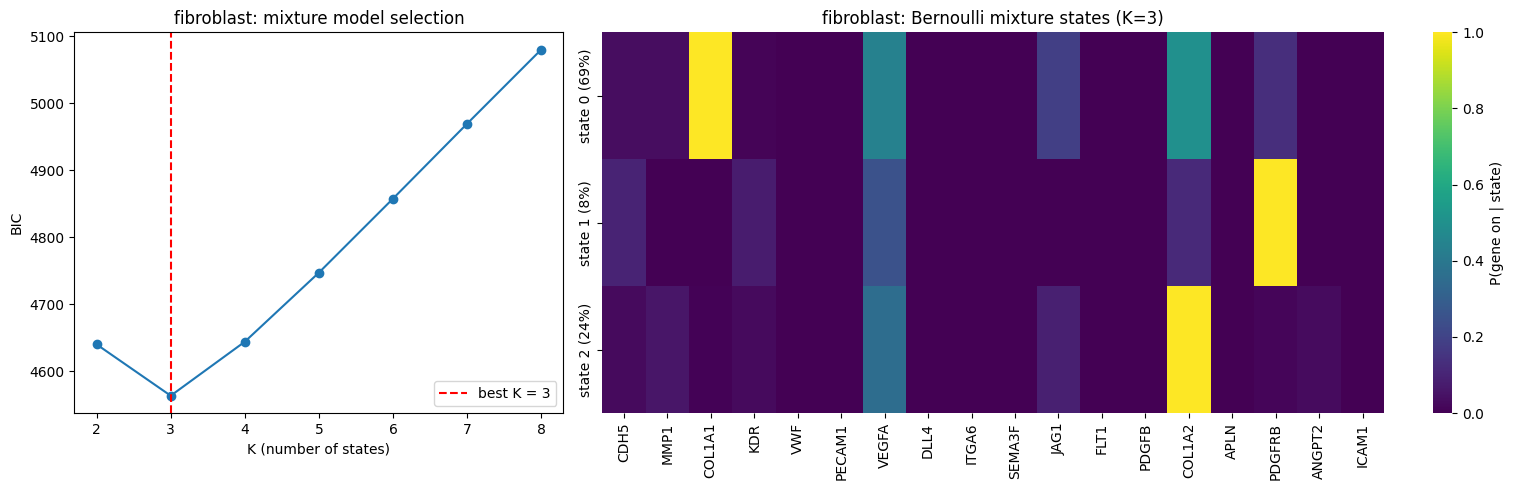

3 clusters identified for fibroblast cells (KMeans, 685 cells):
  cluster 0 (276 cells, 40%): likely states include 28% 3_7 (COL1A1, VEGFA); 20% 3_7_14 (COL1A1, VEGFA, COL1A2); 17% 7_14 (VEGFA, COL1A2)
  cluster 2 (258 cells, 38%): likely states include 40% 3_14 (COL1A1, COL1A2); 29% 14 (COL1A2); 10% 3_11_14 (COL1A1, JAG1, COL1A2)
  cluster 1 (151 cells, 22%): likely states include 52% 3 (COL1A1); 17% 16 (PDGFRB); 8% 3_11 (COL1A1, JAG1)

Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): jaccard = 0.483, hamming = 0.432 -> using jaccard

3 clusters identified for fibroblast cells (Hierarchical (jaccard), 685 cells):
  cluster 3 (486 cells, 71%): likely states include 21% 3_14 (COL1A1, COL1A2); 16% 3 (COL1A1); 16% 3_7 (COL1A1, VEGFA)
  cluster 2 (150 cells, 22%): likely states include 51% 14 (COL1A2); 32% 7_14 (VEGFA, COL1A2); 7% 11_14 (JAG1, COL1A2)
  cluster 1 (49 cells, 7%): likely states include 53% 16 (PDGFRB); 22% 7_16 (VEGFA, PDGFRB); 10% 1_16 (CDH5, PDGFRB)



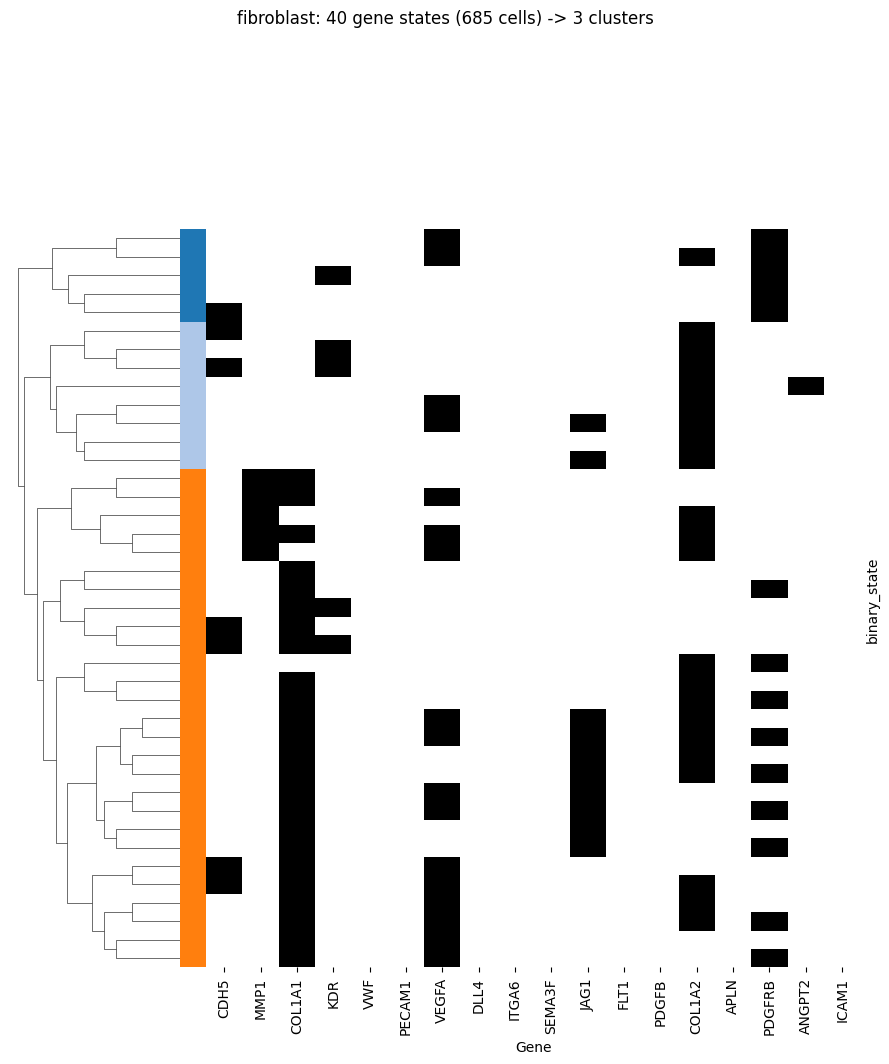

c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\taylorhearn\AppData\Local\miniconda3\envs\sequencing\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


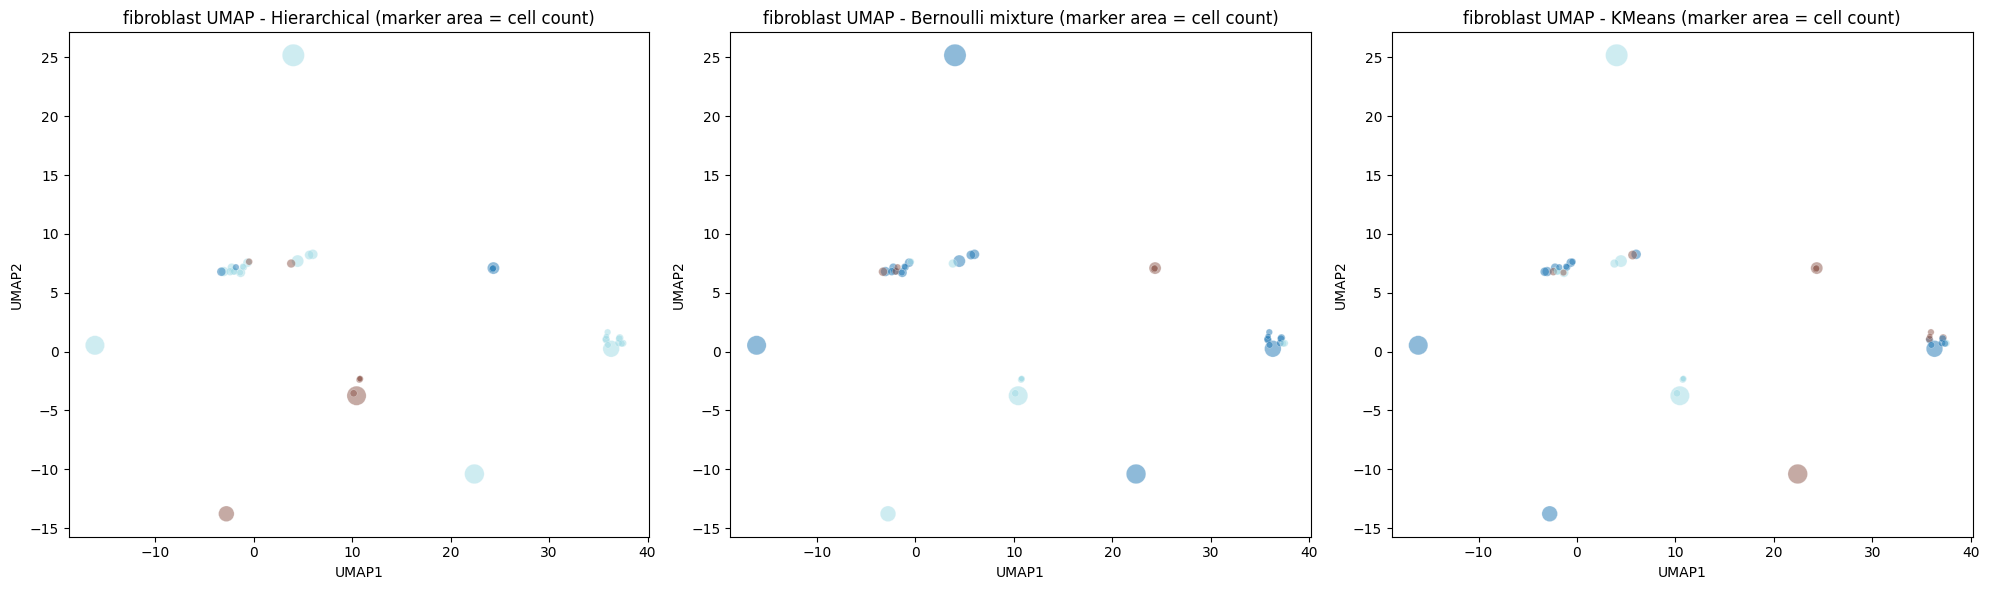

Agreement for fibroblast at K=3 (Adjusted Rand Index, 1 = identical, ~0 = chance):
        kmeans vs bernoulli   : ARI = 0.040
        kmeans vs hierarchical: ARI = 0.038
     bernoulli vs hierarchical: ARI = 0.929

Saved -> section2_cluster_overview.csv


In [35]:
# ============================================================================
# RUN SECTION 2 - all approaches, SPLIT BY CELL TYPE, MATCHED ON GRANULARITY.
#
# To compare the methods fairly we let the Bernoulli mixture pick the number of
# states K (via BIC), then force that same K on the other methods so any low
# agreement reflects real disagreement, not a granularity mismatch:
#   1. Bernoulli mixture      - probabilistic; K chosen by BIC (drives everything).
#   2. KMeans                 - Euclidean clustering of the 0/1 gene vectors at K.
#   3. Hierarchical           - gene states grouped into K clusters. Both Jaccard and
#                               Hamming are tried and whichever agrees more is kept.
#   4. Agreement (ARI)        - at matched K, do the three methods agree? ARI well
#                               above 0 => cell states are robust to the method.
#
# UMAP (Jaccard) is shown alongside for visualisation only.
# MAX_CLUSTERS caps the BIC search so every method stays readable (< 10 clusters).
# ============================================================================

CELL_TYPES = ["endothelial", "fibroblast"]
MAX_CLUSTERS = 8

# Columns section 3 reads later; filled per cell type below (ids offset so they stay
# unique across cell types).
for column in ["hier", "bmm", "kmeans"]:
    df[column] = -1
df["umap1"] = np.nan
df["umap2"] = np.nan

all_summaries = []

for cell_type in CELL_TYPES:
    cells = df[df.cell_type == cell_type]
    if len(cells) < 10:
        print(f"{cell_type}: only {len(cells)} cells - skipping\n")
        continue
    cell_gene_matrix = cells[GENES].astype(int).to_numpy()
    print("=" * 78)
    print(f"CELL TYPE: {cell_type}  ({len(cells):,} cells)")
    print("=" * 78)

    # --- Approach 1: Bernoulli mixture first - BIC picks K, forced on the rest ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        cell_gene_matrix, candidate_states=range(2, MAX_CLUSTERS + 1))
    bmm_labels = best_mixture["labels"]
    K = best_mixture["n_states"]
    print(f"Bernoulli BIC picked K = {K}; forcing K on KMeans and hierarchical.\n")
    all_summaries.append(describe_clusters(cells, bmm_labels, GENES, "Bernoulli mixture", cell_type))

    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
    axes[0].plot(candidate_ks, bic_values, "o-")
    axes[0].axvline(K, color="red", ls="--", label=f"best K = {K}")
    axes[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{cell_type}: mixture model selection")
    axes[0].legend()
    component_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=GENES,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    sns.heatmap(component_probabilities, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
                cbar_kws={"label": "P(gene on | state)"})
    axes[1].set_title(f"{cell_type}: Bernoulli mixture states (K={K})")
    plt.tight_layout(); plt.show()

    # --- Approach 2: KMeans on the gene vectors, forced to the same K ---
    kmeans_labels = kmeans_cluster_gene_space(cell_gene_matrix, n_clusters=K)
    all_summaries.append(describe_clusters(cells, kmeans_labels, GENES, "KMeans", cell_type))

    # --- Approach 3: hierarchical at K - try both metrics, keep the more agreeing one ---
    hier_options = {}
    for metric in ["jaccard", "hamming"]:
        labels_metric, plot_metric = hierarchical_cell_labels(cells, GENES, metric=metric, max_clusters=K)
        mean_ari = np.mean([
            adjusted_rand_score(labels_metric, bmm_labels),
            adjusted_rand_score(labels_metric, kmeans_labels),
        ])
        hier_options[metric] = (labels_metric, plot_metric, mean_ari)
    hier_metric = max(hier_options, key=lambda m: hier_options[m][2])
    hier_labels, hier_plot, _ = hier_options[hier_metric]
    print(f"Hierarchical metric agreement (mean ARI vs Bernoulli & KMeans): "
          f"jaccard = {hier_options['jaccard'][2]:.3f}, hamming = {hier_options['hamming'][2]:.3f} "
          f"-> using {hier_metric}\n")
    all_summaries.append(describe_clusters(cells, hier_labels, GENES, f"Hierarchical ({hier_metric})", cell_type))
    if hier_plot is not None:
        plot_state_clustermap(*hier_plot, cell_type, len(cells))

    # UMAP: collapse identical gene states to one marker, sized by how many cells share it.
    k_neighbors = min(15, len(cells) - 1)
    embedding = umap_embed_gene_space(cell_gene_matrix, k_neighbors=k_neighbors)
    plot_points = pd.DataFrame({
        "umap1": embedding[:, 0], "umap2": embedding[:, 1],
        "state": cells["binary_state"].to_numpy(),
        "hier": hier_labels, "bmm": bmm_labels, "kmeans": kmeans_labels,
    })
    state_points = (plot_points
        .groupby("state", as_index=False)
        .agg(umap1=("umap1", "first"), umap2=("umap2", "first"),
             hier=("hier", "first"), bmm=("bmm", "first"),
             kmeans=("kmeans", "first"), n_cells=("state", "size"))
        .sort_values("n_cells", ascending=False))
    marker_sizes = 15 + 240 * state_points["n_cells"] / state_points["n_cells"].max()

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for ax, column_name, name in zip(axes, ["hier", "bmm", "kmeans"],
                                     ["Hierarchical", "Bernoulli mixture", "KMeans"]):
        ax.scatter(state_points["umap1"], state_points["umap2"], s=marker_sizes,
                   c=state_points[column_name], cmap="tab20", alpha=0.5,
                   edgecolor="white", linewidth=0.3)
        ax.set_title(f"{cell_type} UMAP - {name} (marker area = cell count)")
        ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    plt.tight_layout(); plt.show()

    # --- Approach 4: at matched K, do the methods agree within this cell type? ---
    print(f"Agreement for {cell_type} at K={K} (Adjusted Rand Index, 1 = identical, ~0 = chance):")
    method_labels = {"hierarchical": hier_labels, "bernoulli": bmm_labels, "kmeans": kmeans_labels}
    for method_a, method_b in [("kmeans", "bernoulli"), ("kmeans", "hierarchical"), ("bernoulli", "hierarchical")]:
        labels_a, labels_b = method_labels[method_a], method_labels[method_b]
        both_assigned = (labels_a >= 0) & (labels_b >= 0)
        ari = adjusted_rand_score(labels_a[both_assigned], labels_b[both_assigned])
        print(f"  {method_a:>12} vs {method_b:<12}: ARI = {ari:.3f}")
    print()

    # Store labels back on df (offset so cell types keep distinct ids for section 3).
    hier_offset = int(df["hier"].max()) + 1
    bmm_offset = int(df["bmm"].max()) + 1
    kmeans_offset = int(df["kmeans"].max()) + 1
    df.loc[cells.index, "hier"] = np.where(hier_labels >= 0, hier_labels + hier_offset, -1)
    df.loc[cells.index, "bmm"] = bmm_labels + bmm_offset
    df.loc[cells.index, "kmeans"] = kmeans_labels + kmeans_offset
    df.loc[cells.index, "umap1"] = embedding[:, 0]
    df.loc[cells.index, "umap2"] = embedding[:, 1]

# One tidy, readable table of every cluster from every method and cell type.
cluster_overview = pd.concat(all_summaries, ignore_index=True)
cluster_overview.to_csv(output_dir / "section2_cluster_overview.csv", index=False)
print("Saved -> section2_cluster_overview.csv")

### What the results mean (cautious interpretation!!)

**Are the cell states robust?** Because K is fixed by the Bernoulli mixture (BIC) and *forced* on the other methods, the Adjusted Rand Index (ARI) now measures genuine agreement rather than a difference in granularity. Jaccard beat Hamming for both lineages (endothelial 0.10 vs 0.07, fibroblast 0.48 vs 0.43), i.e. **co-activation of specific markers - not the shared silence of most genes - is what defines the states.**

**Endothelial cells (K = 7).** The three methods agree only modestly (KMeans↔Bernoulli ARI ≈ 0.40, the others ≈ 0.10). This is expected biology: endothelial cells sit on a *continuum* rather than in sharp clusters. The recurring programmes the methods do surface are interpretable, though:
- a **tip/angiogenic** signature (`KDR`/VEGFR2, often with `VEGFA`, `DLL4`),
- a **generic/stalk** signature dominated by `CDH5` (VE-cadherin),
- a **haemostatic / venous** signature marked by `VWF` (± `PECAM1`),
- and smaller `PDGFB`- and `FLT1`(VEGFR1)-driven states.

Modest ARI + a smooth UMAP means these are better read as **axes of endothelial activation** (tip↔stalk, arterial↔venous) than as discrete cell types.

**Fibroblast cells (K = 3).** Here **Bernoulli and hierarchical agree almost perfectly (ARI ≈ 0.93)**, so this partition is highly robust:
- a large **collagen-high matrix** state (`COL1A1` + `COL1A2`),
- a `COL1A2`-dominant state, and
- a distinct **`PDGFRB`+ (perivascular / activated) fibroblast** state.
KMeans disagrees (ARI ≈ 0.04) only because Euclidean distance splits fibroblasts by whether the common gene `VEGFA` is on; the marker-driven Bernoulli/hierarchical pair is the result to trust.

**Bottom line.** Fibroblasts fall into a few genuinely discrete, reproducible states, whereas endothelial cells form a continuum of activation programmes. The `PDGFRB`+ fibroblast and `KDR`/`VEGFA`+ angiogenic endothelial states are the most biologically distinct subpopulations and the natural candidates to follow up spatially in the neighbourhood analysis below.


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


In [ ]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endothelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sc0 = axes[0].scatter(df.umap1, df.umap2, s=6, c=df["nb_entropy"], cmap="magma")
plt.colorbar(sc0, ax=axes[0]); axes[0].set_title("UMAP - neighbourhood entropy")
sc1 = axes[1].scatter(df.umap1, df.umap2, s=6, c=df["nb_%endothelial"], cmap="Reds")
plt.colorbar(sc1, ax=axes[1]); axes[1].set_title("UMAP - % endothelial neighbours")
sc2 = axes[2].scatter(df.umap1, df.umap2, s=6, c=np.log1p(df["nb_density"]), cmap="viridis")
plt.colorbar(sc2, ax=axes[2]); axes[2].set_title("UMAP - log(1 + local density)")
for a in axes:
    a.set_xlabel("UMAP1"); a.set_ylabel("UMAP2")
plt.tight_layout(); plt.show()


In [ ]:
# Cluster the NEIGHBOURHOODS (not the cells) to define recurring micro-environments
# ("niches"), then ask how a cell's gene state relates to the niche it sits in. This
# links gene state <-> tissue context.

nb_feature_cols = ([f"nb_%{c}" for c in CT_ORDER] +
                   [f"nb_{g}" for g in GENES] + ["nb_entropy", "nb_density"])
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche.
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile.T, cmap="vlag", center=0, robust=True,
            cbar_kws={"label": "mean (raw units)"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

# Link gene-state cluster (KMeans) to niche.
plt.figure(figsize=(9, 6))
sns.heatmap(pd.crosstab(df["kmeans"], df["niche"], normalize="index"),
            annot=True, fmt=".2f", cmap="Blues")
plt.title("P(niche | gene-state KMeans cluster)")
plt.xlabel("niche"); plt.ylabel("KMeans cluster")
plt.tight_layout(); plt.show()

In [ ]:
# Do whole gene STATES co-locate in space? Rather than looking at single genes, we
# test complete states: for each of the most common states we measure the fraction of
# a cell's spatial neighbours carrying each other state, then compare to that state's
# global abundance. log2(observed / expected) > 0 means the two states sit together in
# tissue more than chance - so we can ask e.g. whether 1_4_7 and 1_4_8 co-locate.
top_states = df["state_code"].value_counts().head(15).index.tolist()
state_of = df["state_code"].values
global_freq = df["state_code"].value_counts(normalize=True)

obs = pd.DataFrame(0.0, index=top_states, columns=top_states)
cnt = pd.Series(0, index=top_states, dtype=float)
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb
    gneigh = ii[neigh]
    for row, centre_state in zip(gneigh, state_of[ii]):
        if centre_state not in top_states:
            continue
        cnt[centre_state] += 1
        nbr_states = state_of[row]
        for t in top_states:
            obs.loc[centre_state, t] += np.mean(nbr_states == t)

obs = obs.div(cnt.replace(0, np.nan), axis=0)
enrich = np.log2(obs.div(global_freq[top_states], axis=1) + 1e-6)

plt.figure(figsize=(10, 8))
sns.heatmap(enrich, cmap="coolwarm", center=0,
            cbar_kws={"label": "log2 observed / expected"})
plt.title("Spatial co-location of gene states (neighbour enrichment)")
plt.xlabel("neighbour state"); plt.ylabel("centre-cell state")
plt.tight_layout(); plt.show()


## 4. Graph-based approaches

Two complementary graphs:

* **Spatial graph** - nodes = cells, edges = cells within a chosen radius in the same
  image. Used for spatial communities (Leiden), a cell-type **neighbour-enrichment**
  permutation test, and local density.
* **State graph** - nodes = unique gene states, edges connect states differing by a
  single gene (`1` -> `1_4` -> `1_4_7`). Node size = abundance; colour = mean local
  density or % endothelial, revealing how states relate and where they sit in tissue.


In [ ]:
# GRAPH VIEW 1 - spatial graph. Nodes = cells, edges = cell pairs within RADIUS_UM in
# the SAME image. We (a) detect spatial communities with Leiden, (b) run a cell-type
# neighbour-enrichment permutation test (are endothelial cells next to fibroblasts more
# or less than chance?), and (c) visualise the largest image.

# Build one combined spatial graph (node ids = df row index); edges stay within images.
edges_sp = []
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    for a, b in tree.query_pairs(RADIUS_UM):
        edges_sp.append((int(ii[a]), int(ii[b])))

g_sp = ig.Graph(n=len(df), edges=edges_sp)
sp_part = leidenalg.find_partition(g_sp, leidenalg.RBConfigurationVertexPartition,
                                   resolution_parameter=1.0, seed=0)
df["spatial_community"] = np.array(sp_part.membership)
print(f"Spatial graph: {g_sp.ecount():,} edges, "
      f"{df['spatial_community'].nunique()} communities")

# Cell-type neighbour-enrichment permutation test (squidpy-style z-scores).
ct_cat = df["cell_type"].astype("category")
codes = ct_cat.cat.codes.to_numpy()
cats = list(ct_cat.cat.categories)
E = np.array(g_sp.get_edgelist())

def _edge_counts(lbl):
    m = np.zeros((len(cats), len(cats)))
    for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
        m[u, v] += 1
        m[v, u] += 1
    return m

obs_m = _edge_counts(codes)
rng = np.random.default_rng(0)
perm = np.stack([_edge_counts(rng.permutation(codes)) for _ in range(200)])
z = (obs_m - perm.mean(0)) / (perm.std(0) + 1e-9)
z_df = pd.DataFrame(z, index=cats, columns=cats)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
            ax=axes[0], cbar_kws={"label": "enrichment z-score"})
axes[0].set_title("Cell-type neighbour enrichment (200 permutations)")

# Visualise the largest image in space, coloured by cell type.
big = df[IMAGE_KEY].value_counts().idxmax()
sub = df[df[IMAGE_KEY] == big]
for ct in CT_ORDER:
    s = sub[sub.cell_type == ct]
    axes[1].scatter(s.x_um, s.y_um, s=10, color=CT_COLORS[ct], label=ct, alpha=0.7)
axes[1].set_aspect("equal")
axes[1].legend(markerscale=2)
axes[1].set_title(f"Image '{big}' - cells in space")
axes[1].set_xlabel("x (um)"); axes[1].set_ylabel("y (um)")
plt.tight_layout(); plt.show()


In [ ]:
# GRAPH VIEW 2 - state graph. Nodes = unique recurrent gene states; edges connect
# states differing by exactly ONE gene (Hamming distance 1), so the graph maps how
# states are built up gene-by-gene (e.g. 1 -> 1_4 -> 1_4_7). Node size = abundance;
# we colour once by mean local density and once by % endothelial cells in the state.

state_stats = (
    df.groupby("state_code")
    .agg(n_cells=("state_code", "size"),
         density=("nb_density", "mean"),
         pct_epi=("cell_type", lambda s: (s == "endothelial").mean()))
    .reset_index()
)
# One binary vector per state (states are unique on binary_state).
state_vec = {
    sc: np.array([int(c) for c in df.loc[df.state_code == sc, "binary_state"].iloc[0]])
    for sc in state_stats["state_code"]
}

G = nx.Graph()
for r in state_stats.itertuples():
    G.add_node(r.state_code, n=r.n_cells, density=r.density, pct_epi=r.pct_epi)
for s1, s2 in combinations(state_stats["state_code"].tolist(), 2):
    if int(np.abs(state_vec[s1] - state_vec[s2]).sum()) == 1:
        G.add_edge(s1, s2)

pos = nx.spring_layout(G, seed=0, k=0.5)
sizes = np.array([G.nodes[n]["n"] for n in G], dtype=float)
sizes = 20 + 400 * sizes / sizes.max()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, key, cmap in [(axes[0], "density", "viridis"),
                      (axes[1], "pct_epi", "coolwarm")]:
    vals = [G.nodes[n][key] for n in G]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                   node_color=vals, cmap=cmap)
    plt.colorbar(nodes, ax=ax, label=key)
    ax.set_title(f"State graph - node size = abundance, colour = {key}")
    ax.axis("off")
plt.tight_layout(); plt.show()

print(f"State graph: {G.number_of_nodes()} states, "
      f"{G.number_of_edges()} single-gene transitions")


In [ ]:
# Recurrent-state heatmap: rows = states, columns = genes 1-18, values = on/off.
# A side annotation shows n_cells and % of all cells, making families (e.g. 1_4,
# 1_4_7, 1_4_11, 1_4_12) easy to spot.
top_n = 20
top_states = state_summary.head(top_n).copy()

state_onoff = pd.DataFrame(
    [[int(ch) for ch in bs] for bs in top_states["binary_state"]],
    columns=[f"{i + 1}:{g}" for i, g in enumerate(true_gene_columns)],
    index=top_states["state_code"],
)

fig, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(12, 0.45 * top_n + 2),
    gridspec_kw={"width_ratios": [4, 1.4], "wspace": 0.05}, sharey=True,
    constrained_layout=True,
)

ax_hm.imshow(state_onoff.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax_hm.set_xticks(range(len(state_onoff.columns)))
ax_hm.set_xticklabels(state_onoff.columns, rotation=90, fontsize=8)
ax_hm.set_yticks(range(len(state_onoff.index)))
ax_hm.set_yticklabels(state_onoff.index, fontsize=8)
ax_hm.set_xlabel("Gene (index : name)")
ax_hm.set_ylabel("State code")
ax_hm.set_title(f"Top {top_n} recurrent states (black = on)")

y = np.arange(len(top_states))
ax_bar.barh(y, top_states["n_cells"], color="steelblue")
ax_bar.set_xlabel("n cells")
ax_bar.set_title("Frequency")
for yi, (n, pct) in enumerate(zip(top_states["n_cells"], top_states["pct_all_cells"])):
    ax_bar.text(n, yi, f" {n} ({pct:.1f}%)", va="center", fontsize=7)
ax_bar.set_ylim(ax_hm.get_ylim())  # align bars with heatmap rows
plt.show()



In [ ]:
# Cluster the recurrent states using Hamming distance on the 18-gene binary
# vectors with average-linkage hierarchical clustering.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

state_vectors = np.array(
    [[int(ch) for ch in bs] for bs in state_summary["binary_state"]], dtype=np.uint8
)

dist_condensed = pdist(state_vectors, metric="hamming")
Z = linkage(dist_condensed, method="average")
state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

dist_matrix = squareform(dist_condensed)
np.fill_diagonal(dist_matrix, np.inf)
state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

# Per-cluster summary.
cluster_summary = (
    state_summary.groupby("cluster_id")
    .agg(
        n_states=("state_code", "size"),
        n_cells=("n_cells", "sum"),
        example_states=("state_code", lambda s: ", ".join(s.head(5))),
    )
    .reset_index()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
cluster_summary["pct_all_cells"] = 100 * cluster_summary["n_cells"] / n_total

# Dendrogram of recurrent states.
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=state_summary["state_code"].values, color_threshold=hamming_threshold, ax=ax)
ax.axhline(hamming_threshold, color="red", ls="--", lw=1, label=f"cut = {hamming_threshold}")
ax.set_xlabel("State code")
ax.set_ylabel("Hamming distance")
ax.set_title("Hierarchical clustering of recurrent states (Hamming, average linkage)")
ax.legend()
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()

print(f"{len(state_summary)} recurrent states -> {state_summary['cluster_id'].nunique()} clusters")
display(cluster_summary.head(20))

# Save outputs.
state_summary.to_csv(output_dir / "recurrent_states_summary.csv", index=False)
cluster_summary.to_csv(output_dir / "recurrent_state_clusters.csv", index=False)
print("Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv")
